# NB5: Publication Figures

**Narrative Framing**
* What question this notebook addresses: This notebook implements the specified sections to address the statistical analysis of the ground truth transition and performance impact.
* Which GT is being used as primary: Platinum GT
* Which KL1 strategy is active: Explicitly switchable (Default Strategy A - Exclusion)
* Central Narrative: Public medical imaging repository labels contain systematic, directionally biased noise that is invisible without platinum standard validation, and this noise quantifiably corrupts the performance metrics of annotation studies, AI benchmarks, and psychometric predictors derived from them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from sklearn.metrics import accuracy_score
import os
import helpers
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# 1. Load Data
df = helpers.load_data('exclude')
df_img = helpers.image_summary(df)

if not os.path.exists('figures'):
    os.makedirs('figures')

print("Setup Complete: Ready to export figures to /figures/ folder.")

Setup Complete: Ready to export figures to /figures/ folder.


## Figure generation

--- Generating Figure 1: Transition Heatmap ---


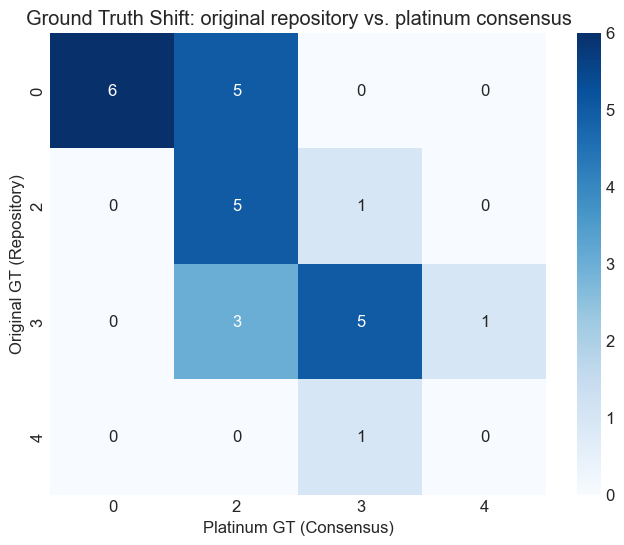


--- Generating Figure 2: The Accuracy Paradox ---


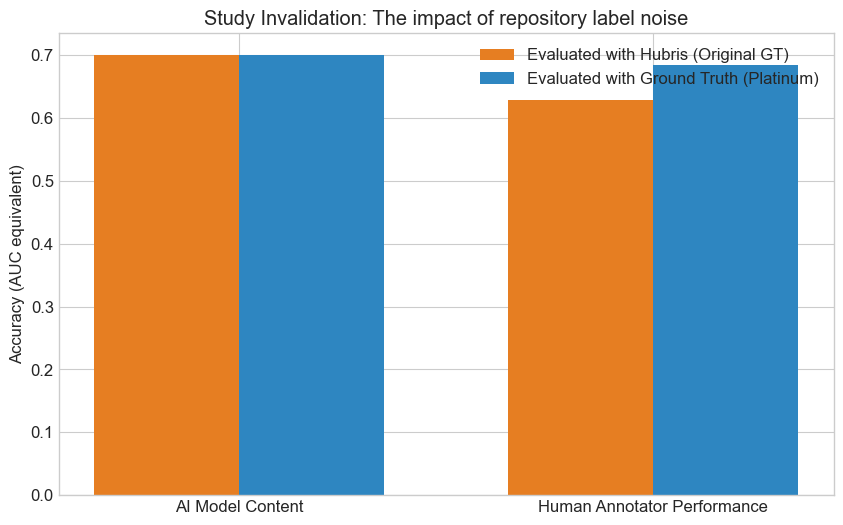


--- Generating Figure 3: Core Study Result ---


/var/folders/1g/t32yf_mn5pd5ymkl2yywtctr0000gn/T/ipykernel_34072/941114313.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Control (No AI)', 'Experimental (With AI)'])


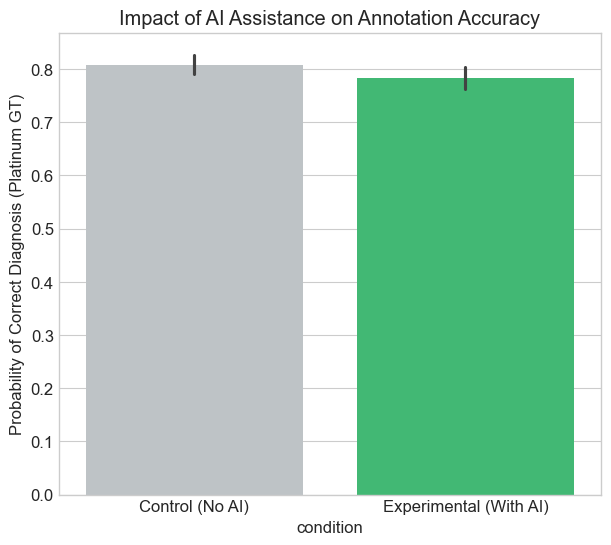

In [2]:
print("--- Generating Figure 1: Transition Heatmap ---")
fig1, ax = plt.subplots(figsize=(8,6))
sns.heatmap(pd.crosstab(df_img['gt_original'], df_img['gt_plat_kl']), annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title("Ground Truth Shift: original repository vs. platinum consensus")
ax.set_xlabel("Platinum GT (Consensus)")
ax.set_ylabel("Original GT (Repository)")
fig1.savefig('figures/Fig1_Transition.pdf', bbox_inches='tight')
fig1.savefig('figures/Fig1_Transition.png', bbox_inches='tight', dpi=300)
plt.show()

print("\n--- Generating Figure 2: The Accuracy Paradox ---")
df_clin = helpers.load_data('clinical') 
o_acc = accuracy_score(df_clin['gt_original_binary'], df_clin['ai_prediction'])
p_acc = accuracy_score(df_clin['gt_plat_binary'], df_clin['ai_prediction'])
h_o_acc = accuracy_score(df_clin['gt_original_binary'], df_clin['final_decision'])
h_p_acc = accuracy_score(df_clin['gt_plat_binary'], df_clin['final_decision'])

x = ['AI Model Content', 'Human Annotator Performance']
y_o = [o_acc, h_o_acc]
y_p = [p_acc, h_p_acc]

fig2, ax = plt.subplots(figsize=(10,6))
width = 0.35
ax.bar(np.arange(len(x)), y_o, width, label='Evaluated with Hubris (Original GT)', color='#E67E22')
ax.bar(np.arange(len(x)) + width, y_p, width, label='Evaluated with Ground Truth (Platinum)', color='#2E86C1')
ax.set_xticks(np.arange(len(x)) + width/2)
ax.set_xticklabels(x)
ax.set_ylabel('Accuracy (AUC equivalent)')
ax.set_title('Study Invalidation: The impact of repository label noise')
ax.legend()
fig2.savefig('figures/Fig2_AccuracyParadox.pdf', bbox_inches='tight')
fig2.savefig('figures/Fig2_AccuracyParadox.png', bbox_inches='tight', dpi=300)
plt.show()

print("\n--- Generating Figure 3: Core Study Result ---")
fig3, ax = plt.subplots(figsize=(7,6))
sns.barplot(data=df, x='condition', y='human_correct_plat', palette=['#BDC3C7', '#2ECC71'], ax=ax)
ax.set_title("Impact of AI Assistance on Annotation Accuracy")
ax.set_ylabel("Probability of Correct Diagnosis (Platinum GT)")
ax.set_xticklabels(['Control (No AI)', 'Experimental (With AI)'])
fig3.savefig('figures/Fig3_CoreResult.pdf', bbox_inches='tight')
fig3.savefig('figures/Fig3_CoreResult.png', bbox_inches='tight', dpi=300)
plt.show()